<a href="https://colab.research.google.com/github/BialaStrzala/Sztuczna-Inteligencja-Paula-Grzebyk-21236/blob/main/Si_regresja_liniowa_tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Paula Grzebyk 21236
**Uproszczona regresja liniowa z użyciem biblioteki Tensorflow**

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [49]:
observations = 1000
xs = np.random.uniform(low=-10, high=10, size=(observations,1))
zs = np.random.uniform(low=-10, high=10, size=(observations,1))
inputs = np.column_stack((xs, zs))
print(inputs.shape)

noise = np.random.uniform(low=-1, high=1, size=(observations,1))
targets = 13*xs + 7*zs - 12 + noise
np.savez('TF_dataset', inputs=inputs, targets=targets)
print(targets.shape)

(1000, 2)
(1000, 1)


# Eksperyment 1
targets = 13*xs + 7*zs - 12 + noise

Funkcja optymalizacji: SGD

Funkcja straty: strata kwadratowa

Wyniki wag: [12.995845], [ 7.0063  ], [-11.983423]

In [3]:
training_data = np.load('TF_dataset.npz')
input_size = 2
output_size = 1
model = tf.keras.Sequential([tf.keras.layers.Dense(output_size)])
model.compile(optimizer='sgd', loss='mean_squared_error')
model.fit(training_data['inputs'], training_data['targets'], epochs=100, verbose=1)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 326.4452    
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 24.5347 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.9714  
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.2265 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8627 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4914 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3874 
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3626 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3595 
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3513 
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3545 
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3485 
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3594 
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3516 
Epoch 15/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/ste

In [4]:
model.layers[0].get_weights()

[array([[12.995845],
        [ 7.0063  ]], dtype=float32),
 array([-11.983423], dtype=float32)]

In [5]:
model.predict_on_batch(training_data['inputs']).round(1)

array([[  41.3],
       [   8.7],
       [ -55.3],
       [  -2.2],
       [ -36.4],
       [ 170.6],
       [  46.9],
       [  28. ],
       [   1.7],
       [  45.9],
       [ -89.2],
       [  26.6],
       [ -16.3],
       [-141. ],
       [-129.7],
       [ 131.8],
       [ -22.7],
       [  81.3],
       [  91.2],
       [  27. ],
       [ -75.4],
       [ 162. ],
       [  27. ],
       [ -40.2],
       [ -47.5],
       [ 132. ],
       [  68.6],
       [  -4.6],
       [ -97.7],
       [  18.4],
       [  92.9],
       [  42.3],
       [ -99.1],
       [  39.6],
       [-136.9],
       [  94.1],
       [  44.4],
       [-107.5],
       [-103.6],
       [  -8.5],
       [  38.3],
       [-129.7],
       [ 123.9],
       [-115.6],
       [ -84.3],
       [ -82.7],
       [ -20.2],
       [-153.7],
       [-102. ],
       [  -7.5],
       [  85.4],
       [   7.5],
       [  73.5],
       [  43.4],
       [  55.6],
       [  59.1],
       [  60.1],
       [  87.6],
       [ -96.7

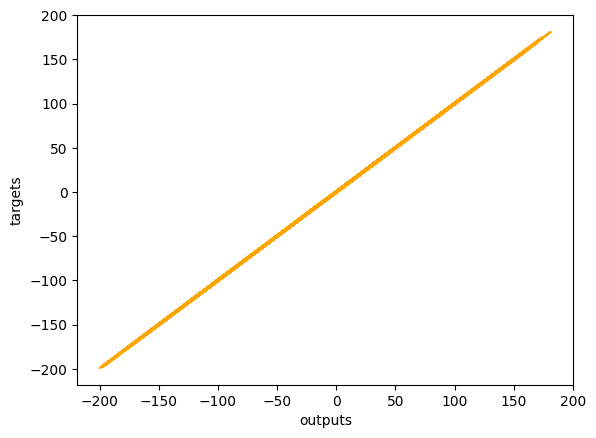

In [6]:
plt.plot(np.squeeze(model.predict_on_batch(training_data['inputs'])), np.squeeze(training_data['targets']), color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()

# Eksperyment 2
targets = 13*xs + 7*zs - 12 + noise

Funkcja optymalizacji: AdamW

Funkcja straty: strata kwadratowa

Wyniki wag: [3.2356822], [3.6468203], [-2.2086816]

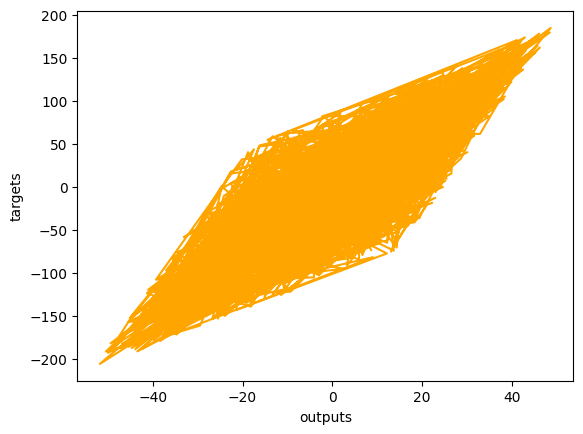

In [12]:
training_data = np.load('TF_dataset.npz')
input_size = 2
output_size = 1
model = tf.keras.Sequential([tf.keras.layers.Dense(output_size)])
model.compile(optimizer='adamw', loss='mean_squared_error')
model.fit(training_data['inputs'], training_data['targets'], epochs=100, verbose=0)
plt.plot(np.squeeze(model.predict_on_batch(training_data['inputs'])), np.squeeze(training_data['targets']), color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()

In [9]:
model.layers[0].get_weights()

[array([[3.2356822],
        [3.6468203]], dtype=float32),
 array([-2.2086816], dtype=float32)]

# Eksperyment 3
targets = 13*xs + 7*zs - 12 + noise

Funkcja optymalizacji: SGD

Funkcja straty: LogCosh

Wyniki wag: [13.004426], [ 7.004412], [-12.034975]

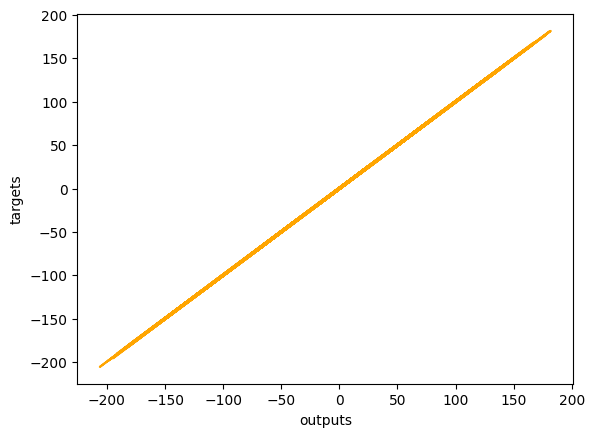

In [15]:
training_data = np.load('TF_dataset.npz')
input_size = 2
output_size = 1
model = tf.keras.Sequential([tf.keras.layers.Dense(output_size)])
model.compile(optimizer='sgd', loss='log_cosh')
model.fit(training_data['inputs'], training_data['targets'], epochs=100, verbose=0)
plt.plot(np.squeeze(model.predict_on_batch(training_data['inputs'])), np.squeeze(training_data['targets']), color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()

In [16]:
model.layers[0].get_weights()

[array([[13.004426],
        [ 7.004412]], dtype=float32),
 array([-12.034975], dtype=float32)]

# Eksperyment 4
targets = 13*xs + 7*zs - 12 + noise

Funkcja optymalizacji: SGD

Funkcja straty: strata kwadratowa

3 warstwy o funkcji aktywacji sigmoidy

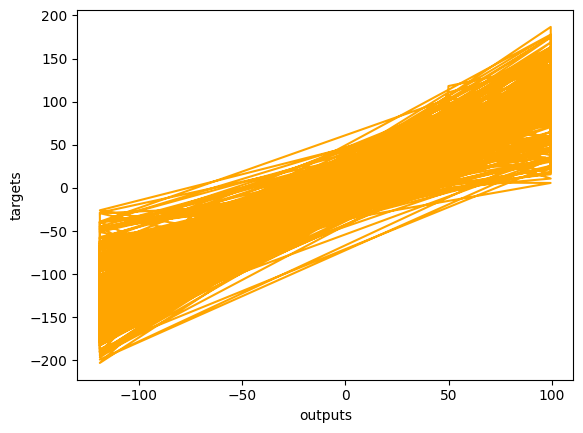

In [27]:
training_data = np.load('TF_dataset.npz')
input_size = 5
output_size = 1
model = tf.keras.Sequential([
    tf.keras.layers.Dense(5, activation='sigmoid'),
    tf.keras.layers.Dense(5, activation='sigmoid'),
    tf.keras.layers.Dense(output_size)
])
model.compile(optimizer='sgd', loss='mean_squared_error')
model.fit(training_data['inputs'], training_data['targets'], epochs=50, verbose=0)
plt.plot(np.squeeze(model.predict_on_batch(training_data['inputs'])), np.squeeze(training_data['targets']), color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()

# Eksperyment 5
targets = 13*xs + 7*zs - 12 + noise

Funkcja optymalizacji: SGD

Funkcja straty: Mean squared logarithmic error

4 warstwy o funkcji aktywacji sigmoidy

In [23]:
model.layers[0].get_weights()

[array([[ 15.971365  ,  -4.077556  , -34.176098  , -17.296724  ,
          27.757832  ],
        [  8.817373  ,  27.087725  ,  -0.17524007, -20.621592  ,
         -11.658569  ]], dtype=float32),
 array([ 8.5333538e+00, -1.3546800e+01, -3.0074844e+00, -1.2512268e-02,
         3.2099504e+00], dtype=float32)]

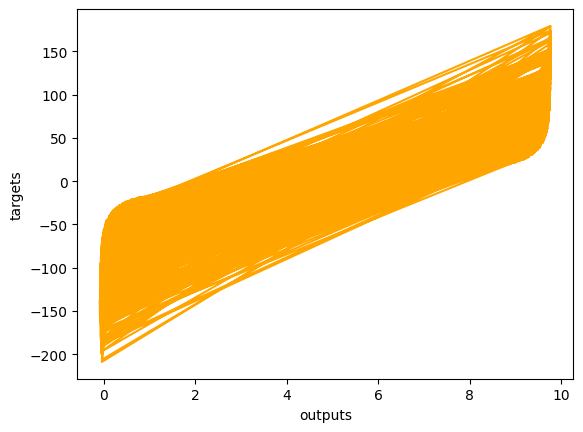

In [50]:
training_data = np.load('TF_dataset.npz')
input_size = 5
output_size = 1
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='sigmoid'),
    tf.keras.layers.Dense(5, activation='sigmoid'),
    tf.keras.layers.Dense(7, activation='sigmoid'),
    tf.keras.layers.Dense(output_size)
])
model.compile(optimizer='sgd', loss='mean_squared_logarithmic_error')
model.fit(training_data['inputs'], training_data['targets'], epochs=100, verbose=0)
plt.plot(np.squeeze(model.predict_on_batch(training_data['inputs'])), np.squeeze(training_data['targets']), color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()

In [51]:
model.layers[0].get_weights()

[array([[ 0.7659437 ,  0.310265  , -0.9449219 , -0.20176022,  0.30810598,
          0.7839565 ,  0.8034374 , -0.58333206, -0.7586759 , -0.8782012 ],
        [ 0.40865037, -0.4760604 , -0.54481196, -0.52385104, -0.82960826,
          0.4301172 ,  0.36326867, -0.26527846, -0.41293103, -0.5011416 ]],
       dtype=float32),
 array([-0.26542085, -0.00558239,  0.34930167, -0.00821228, -0.00225592,
        -0.2753048 , -0.18369319,  0.14209603,  0.24342082,  0.27188787],
       dtype=float32)]